# MNIST Digit Classification with PyTorch

This notebook demonstrates how to build, train, and evaluate a Convolutional Neural Network (CNN) for handwritten digit classification using the MNIST dataset and PyTorch.

---

## Table of Contents

1. [Import Libraries and Setup](#step1)
2. [Load and Explore the MNIST Dataset](#step2)
3. [Visualize Sample Images](#step3)
4. [Prepare DataLoaders](#step4)
5. [Define the CNN Model](#step5)
6. [Set Up Loss, Optimizer, and Metrics](#step6)
7. [Train the Model](#step7)
8. [Evaluate Model Performance](#step8)
9. [Make Predictions and Visualize Results](#step9)
10. [Plot Confusion Matrix](#step10)
11. [Save the Trained Model](#step11)

## 1. Import Libraries and Setup <a id="step1"></a>

First, we import the necessary libraries and set up the device for computation (GPU if available, otherwise CPU).

In [2]:
# Step 1: Import torch and set up device
import torch

# Print PyTorch version to ensure compatibility
print(torch.__version__)

# Setup device agnostic code: use GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.6.0+cpu


'cpu'

## 2. Load and Explore the MNIST Dataset <a id="step2"></a>

We use torchvision to download and load the MNIST dataset. The dataset contains 60,000 training and 10,000 test images of handwritten digits (0-9).

In [3]:
# Step 2: Load MNIST dataset using torchvision
from torchvision import datasets, transforms

# Download and transform training data
train_data = datasets.MNIST(
    root="data",
    train= True,
    transform= transforms.ToTensor(),
    download= True
)

# Download and transform test data
test_data = datasets.MNIST(
    root="data",
    train= False,
    transform= transforms.ToTensor(),
    download= True
)

# Print the number of samples in train and test sets
len(train_data), len(test_data)

(60000, 10000)

## 3. Visualize Sample Images <a id="step3"></a>

Let's inspect a sample image and its label from the training set.

In [4]:
# Step 3: Visualize a random sample from the training data
img, label = train_data[0]

print(f"img = {img}")
print(f"label = {label}")

# Select a random index to visualize
random_index = int(torch.randint(0, len(train_data), size=[1]))
random_index

img = tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0

58249

### Get Class Names

The MNIST dataset contains 10 classes, one for each digit.

In [5]:
# Get class names for MNIST dataset
class_names = train_data.classes

class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

### Plot Example Images

Let's plot a grid of example images from the training set.

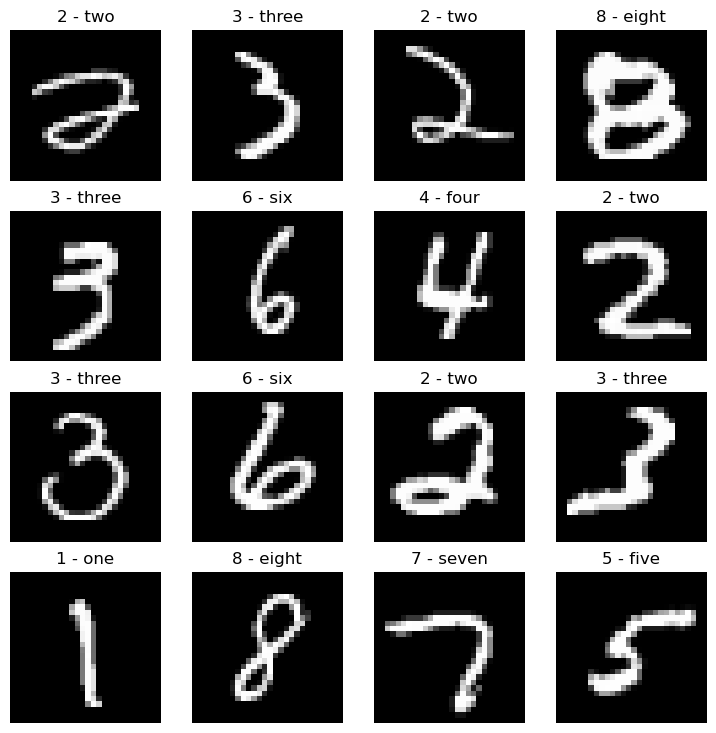

In [6]:
# Plot example images using a helper function
from matplotlib import pyplot as plt
from helper_functions import plot_example

plot_example(train_data=train_data, class_names=class_names)

## 4. Prepare DataLoaders <a id="step4"></a>

We use DataLoader to efficiently load data in batches during training and testing.

In [7]:
# Step 4: Create DataLoaders for batching
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,
                            batch_size = BATCH_SIZE,
                            shuffle = True,
)
test_dataloader = DataLoader(test_data,
                            batch_size = BATCH_SIZE,
                            shuffle = False,
)

# Print DataLoader details
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(60000/32)
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")
print(10000/32) # gets rounded up, and the last batch has less than 32 items in it

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001BE530397F0>, <torch.utils.data.dataloader.DataLoader object at 0x000001BE52A045F0>)
Length of train dataloader: 1875 batches of 32
1875.0
Length of test dataloader: 313 batches of 32
312.5


## 5. Define the CNN Model <a id="step5"></a>

We define a Convolutional Neural Network (CNN) using PyTorch's `nn.Module`. The model consists of two convolutional blocks followed by a fully connected layer.

In [8]:
# Step 5: Define the CNN model for MNIST classification
from torch import nn

class MNIST_model (nn.Module):
    def __init__(self, 
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        
        # First convolutional block
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                    out_channels= hidden_units,
                    kernel_size= 3),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Second convolutional block
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                    out_channels= hidden_units,
                    kernel_size= 3),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Calculate the flattened feature size after conv blocks
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_shape, 28, 28)
            x = self.block_1(dummy_input)
            x = self.block_2(x)
            num_features = x.shape[1] * x.shape[2] * x.shape[3]
            
        # Classifier (fully connected layer)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features= num_features,
                out_features= output_shape
            )
        )
        
    def forward (self, x:torch.Tensor):
        # Forward pass through conv blocks and classifier
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        
        return x
    

# Instantiate the model
number_model = MNIST_model(input_shape=1,
                    hidden_units=32,
                    output_shape=len(class_names))

number_model

MNIST_model(
  (block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=10, bias=True)
  )
)

## 6. Set Up Loss, Optimizer, and Metrics <a id="step6"></a>

We use CrossEntropyLoss for multi-class classification, SGD optimizer, and accuracy as the evaluation metric.

In [9]:
# Step 6: Set up loss function, optimizer, and accuracy metric
from torchmetrics import Accuracy

acc_metric = Accuracy(task="multiclass", num_classes=len(class_names))
loss_fn = nn.CrossEntropyLoss()
optm = torch.optim.SGD(params= number_model.parameters(),
                    lr = 0.1)

## 7. Train the Model <a id="step7"></a>

We train the model for a specified number of epochs using helper functions for training and testing.

In [10]:
# Step 7: Train the model using helper functions
from tqdm.auto import tqdm
from timeit import default_timer as timer
from helper_functions import train_fn, test_fn

start_time_train = timer()
EPOCHS = 5

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch}\n----------------------")
    # Training step
    train_fn(model=number_model,
            accuracy_function= acc_metric,
            loss_function= loss_fn,
            optimizer= optm,
            dataloader= train_dataloader)

    # Testing step
    test_fn(model=number_model,
            accuracy_function= acc_metric,
            loss_function= loss_fn,
            dataloader= test_dataloader)

end_time_train = timer()
total_train_time = end_time_train-start_time_train

minutes = int(total_train_time // 60)
seconds = total_train_time % 60
print(f"Time taken = {minutes} minutes and {seconds:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
----------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.20486 | Train accuracy: 93.55%
Test loss: 0.05164 | Test accuracy: 98.38%

Epoch: 1
----------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.05961 | Train accuracy: 98.17%
Test loss: 0.05085 | Test accuracy: 98.44%

Epoch: 2
----------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.04376 | Train accuracy: 98.60%
Test loss: 0.03775 | Test accuracy: 98.80%

Epoch: 3
----------------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.03503 |

## 8. Evaluate Model Performance <a id="step8"></a>

After training, we evaluate the model's performance on the test set using a helper function.

In [11]:
# Step 8: Evaluate the trained model on the test set
from helper_functions import eval_model

number_model_results = eval_model(model=number_model, 
                            data_loader=test_dataloader,
                            loss_fn=loss_fn, 
                            accuracy_fn=acc_metric
)
number_model_results

{'model_name': 'MNIST_model',
 'model_loss': 0.03463837131857872,
 'model_acc': 98.76999855041504}

## 9. Make Predictions and Visualize Results <a id="step9"></a>

We randomly select 16 test samples, make predictions, and visualize the results.

In [12]:
# Step 9: Select random test samples and view their shapes and labels
import random
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=16): # k=16 to get 16 random samples
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (5 - five)


In [13]:
# Make predictions on test samples using the trained model
from helper_functions import make_predictions

# Make predictions on test samples with model 2
pred_probs= make_predictions(model=number_model, 
                            data=test_samples)

# Get predicted classes by taking the argmax
pred_classes = pred_probs.argmax(dim=1)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[1.7010e-09, 6.1649e-09, 4.5534e-10, 1.5906e-08, 1.0328e-08, 9.9908e-01,
         9.0787e-04, 6.7713e-11, 7.7237e-07, 1.1344e-05],
        [2.3065e-09, 1.8901e-10, 7.8369e-10, 3.4027e-09, 2.2463e-07, 2.7492e-10,
         1.0677e-12, 9.1594e-08, 1.5490e-06, 1.0000e+00]])

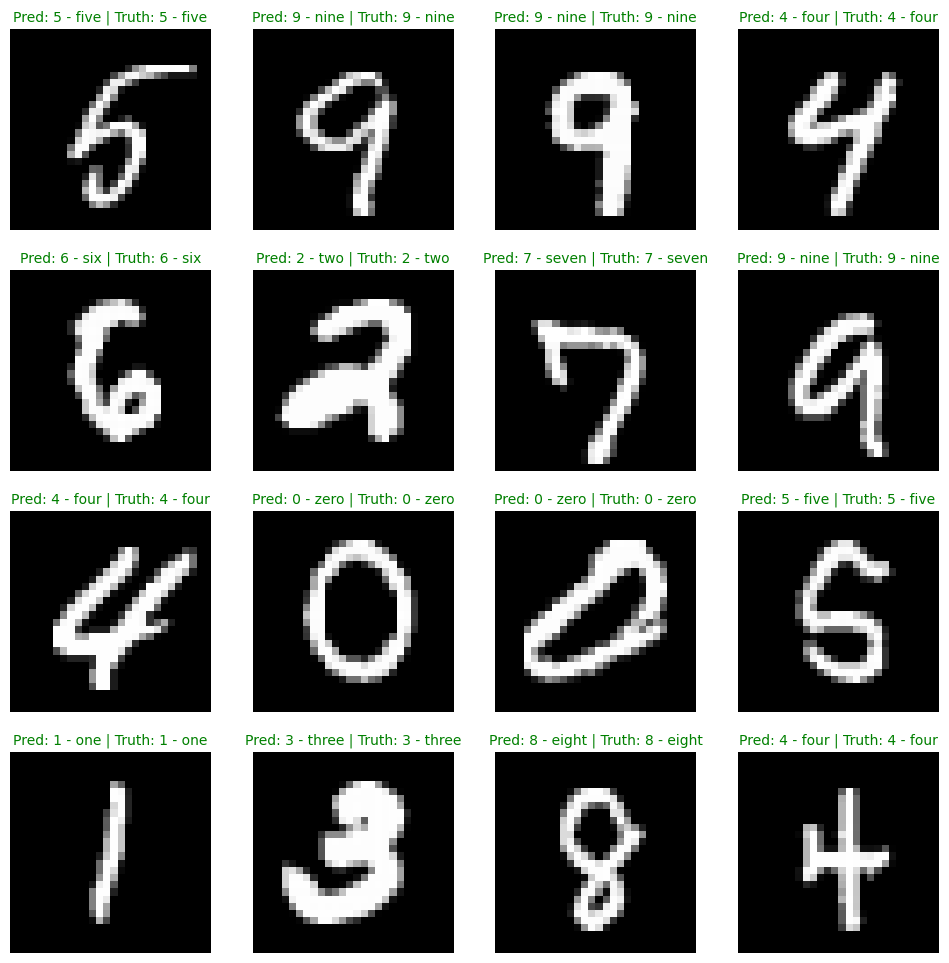

In [14]:
# Visualize predictions vs. true labels for the test samples
from helper_functions import test_model_plot

test_model_plot(test_samples= test_samples, 
                class_names=class_names, 
                pred_classes=pred_classes,
                test_labels=test_labels)

## 10. Plot Confusion Matrix <a id="step10"></a>

Finally, we plot a confusion matrix to visualize the model's performance across all classes.

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

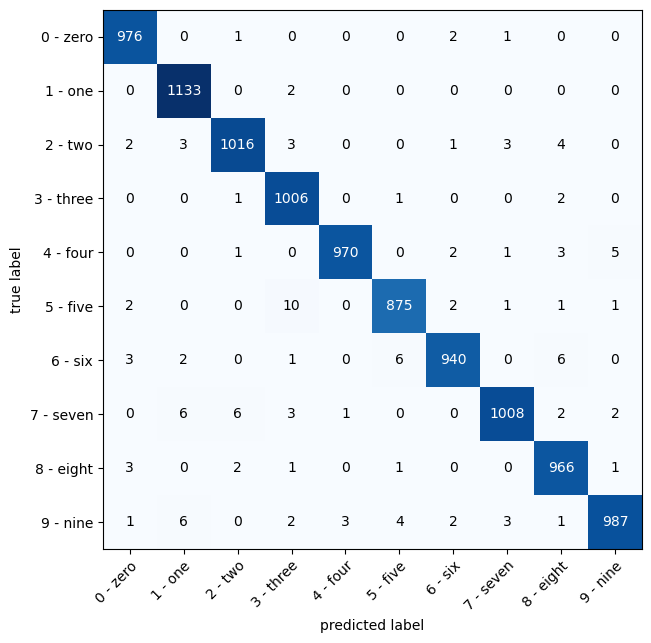

In [15]:
# Step 10: Plot confusion matrix for the test set predictions
from helper_functions import plot_conffusion_matrix

plot_conffusion_matrix(model=number_model, 
                    dataloader=test_dataloader,
                    class_names=class_names,
                    test_data=test_data)

## 11. Save the Trained Model

After evaluating the model, we save the trained model's state dictionary to disk using `torch.save`. This allows us to reload the model later for inference or further training.

In [16]:
# Step 11: Save the trained model to a file
import torch

MODEL_PATH = "MNIST_Model.pth"
torch.save(
    obj= number_model.state_dict(), 
    f= MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to MNIST_Model.pth
